# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [1]:
#Type your code here
!pip install -q scikit-learn==1.7.0
!pip install yellowbrick
from yellowbrick.cluster import KElbowVisualizer
import joblib
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Tampilkan scikit-learn version, akan muncul warning bila bukan 1.7 ke atas
if sklearn.__version__ < '1.7':
    print(f"Warning: scikit-learn version is {sklearn.__version__}. Install kembali scikit-learn dan import.")

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [2]:
# Load data
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)

In [3]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [4]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

<Axes: >

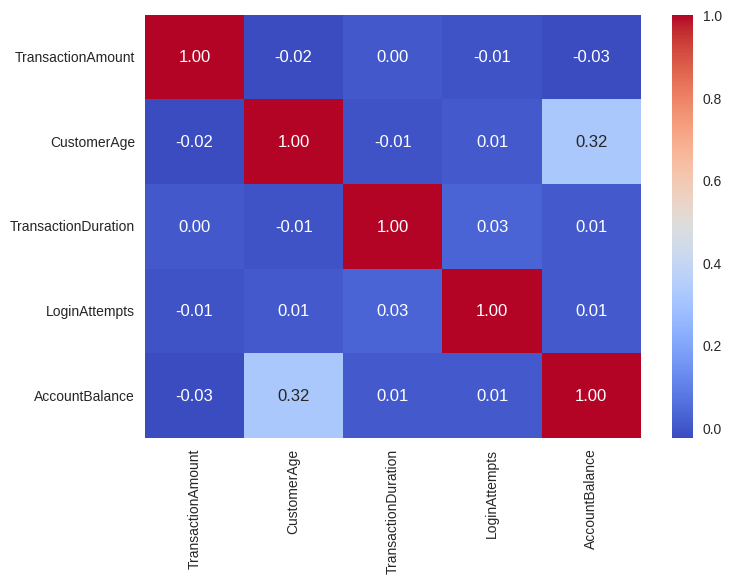

In [6]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)
# menggunakan correlation matrix
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

array([[<Axes: title={'center': 'TransactionAmount'}>,
        <Axes: title={'center': 'CustomerAge'}>],
       [<Axes: title={'center': 'TransactionDuration'}>,
        <Axes: title={'center': 'LoginAttempts'}>],
       [<Axes: title={'center': 'AccountBalance'}>, <Axes: >]],
      dtype=object)

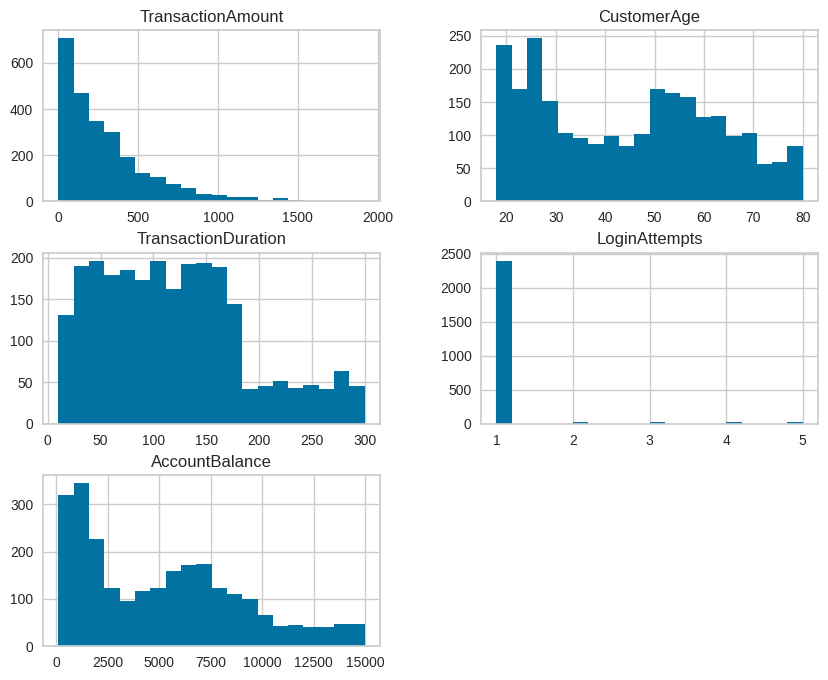

In [7]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)
numerical_cols = df.select_dtypes(include=np.number).columns
df[numerical_cols].hist(figsize=(10, 8), bins=20)


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

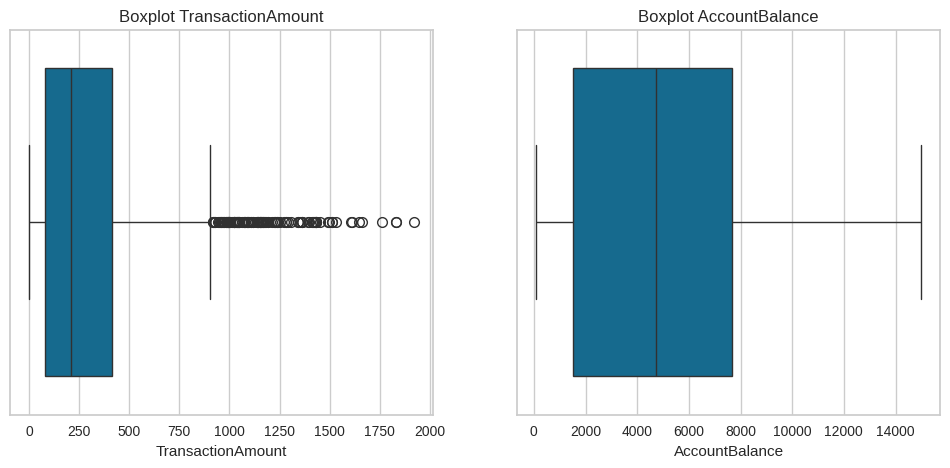

In [8]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)
# disini saya ingin menampilkan bagaimana TransactionAmount berkorelasi dengan AccountBalance
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['TransactionAmount'])
plt.title('Boxplot TransactionAmount')

plt.subplot(1,2,2)
sns.boxplot(x=df['AccountBalance'])
plt.title('Boxplot AccountBalance')

plt.show()


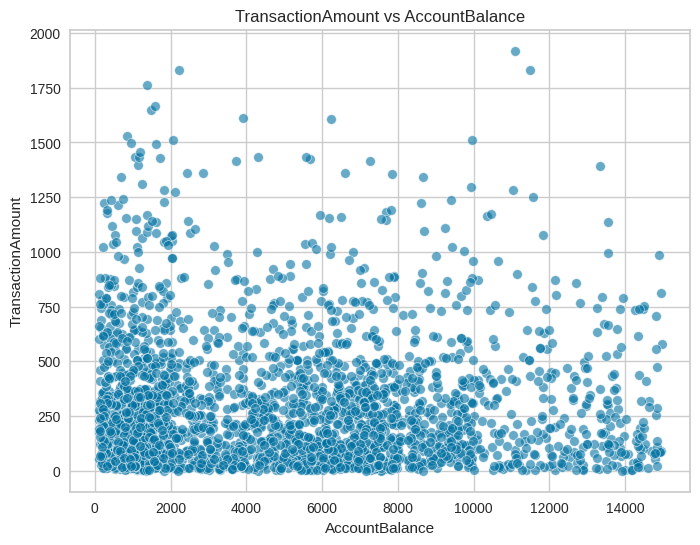

In [9]:
# terlihat bahwa pada boxplot TransactionAmount memiliki banyak outlier
# maka saya menampilkan hubungan antara TransactionAmount dengan AccountBalance
plt.figure(figsize=(8,6))
sns.scatterplot(x='AccountBalance', y='TransactionAmount', data=df, alpha=0.6)
plt.title('TransactionAmount vs AccountBalance')
plt.show()



Dari hasil analisis tambahan tersebut tampak bahwa:

*   Visualisasi dengan Boxplot menunjukkan adanya Outlier pada TransactionAmount yang perlu ditangani
*   Sedangkan pada scatterplot menunjukkan datanya tersebara tanpa membuat garis linear, mengindikasikan kalau pola transaksi nasabah beragam
* Terdapat beberapa transaksi dengan jumlah sangat besar meskipun saldo nasabah relatif kecil. Mengindikasikan adanya fraud, sehingga kedua fitur ini penting untuk dianalisis lebih lanjut

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [10]:
# Mengecek dataset menggunakan isnull().sum()
df.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
TransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [11]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(21)

In [12]:
# Melakukan feature scaling menggunakan MinMaxScaler() atau StandardScalar() untuk fitur numerik.
# Pastikan kamu menggunakan function head setelah melalukan scaling.
# Melakukan feature scaling menggunakan StandardScaler() untuk fitur numerik.
# Pastikan kamu menggunakan function head setelah melakukan scaling.

# Penjelasan:
# - Hanya fitur numerik yang akan dinormalisasi
# - 'LoginAttempts' tidak diikutkan karena nilainya kecil dan memiliki makna khusus
# - StandardScaler membuat distribusi fitur memiliki mean=0 dan std=1,
#   sehingga lebih cocok untuk model berbasis jarak seperti KMeans


# 1. Ambil kolom numerik, kecuali 'LoginAttempts'
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'LoginAttempts' in numerical_cols:
    numerical_cols.remove('LoginAttempts')

print("\nKolom numerik yang dinormalisasi:", numerical_cols)

# 2. Inisialisasi StandardScaler
scaler = StandardScaler()

# 3. Fit dan transform kolom numerik (selain LoginAttempts)
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# 4. Tampilkan hasil untuk memastikan scaling berhasil
print("\nContoh hasil setelah StandardScaler:")
df.head()



Kolom numerik yang dinormalisasi: ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'AccountBalance']

Contoh hasil setelah StandardScaler:


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,-0.970546,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,1.419862,Doctor,-0.548393,1.0,-0.000315,2024-11-04 08:08:08
1,TX000002,AC00455,0.268963,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,1.307715,Doctor,0.307960,1.0,2.218381,2024-11-04 08:09:35
2,TX000003,AC00019,-0.586526,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,-1.439874,Student,-0.905207,1.0,-1.024091,2024-11-04 08:07:04
3,TX000004,AC00070,-0.387294,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,-1.047361,Student,-1.347656,1.0,0.886694,2024-11-04 08:09:06
4,TX000005,AC00411,-0.972736,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,1.121495,1.0,0.594263,2024-11-04 08:06:39


In [13]:
# Melakukan drop pada kolom yang memiliki keterangan id dan IP Address
df.drop([ 'TransactionID','AccountID', 'DeviceID', 'MerchantID', 'IP Address'], axis=1, inplace=True)
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,-0.970546,2023-04-11 16:29:14,Debit,San Diego,ATM,1.419862,Doctor,-0.548393,1.0,-0.000315,2024-11-04 08:08:08
1,0.268963,2023-06-27 16:44:19,Debit,Houston,ATM,1.307715,Doctor,0.307960,1.0,2.218381,2024-11-04 08:09:35
2,-0.586526,2023-07-10 18:16:08,Debit,Mesa,Online,-1.439874,Student,-0.905207,1.0,-1.024091,2024-11-04 08:07:04
3,-0.387294,2023-05-05 16:32:11,Debit,Raleigh,Online,-1.047361,Student,-1.347656,1.0,0.886694,2024-11-04 08:09:06
4,-0.972736,2023-10-16 17:51:24,Credit,Atlanta,Online,NaN,Student,1.121495,1.0,0.594263,2024-11-04 08:06:39


In [14]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
# Pastikan kamu menggunakan function head setelah melalukan encoding.

# melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal
# Jadi kelompokkan dulu kolom yang tipenya kategorikal

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Kolom kategorikal yang akan di-encode:", categorical_cols)

# Siapkan dictionary untuk menyimpan encoder
encoders = {}

# Loop tiap kolom kategorikal
for col in categorical_cols:
    le = LabelEncoder()
    mask_non_null = df[col].notna()

    if mask_non_null.sum() == 0:
        print(f"{col}: semua nilai NaN — dilewati.")
        continue

    # Fit & transform hanya nilai valid
    le.fit(df.loc[mask_non_null, col])
    df.loc[mask_non_null, col] = le.transform(df.loc[mask_non_null, col]).astype(int)
    df.loc[~mask_non_null, col] = np.nan

    # Simpan encoder untuk inverse transform nanti
    encoders[col] = le
    print(f"{col}: encoding selesai. Jumlah kategori = {len(le.classes_)}")

print("\nSemua kolom kategorikal telah di-encode (tanpa mengubah nilai NaN).")
df[categorical_cols].head()


Kolom kategorikal yang akan di-encode: ['TransactionDate', 'TransactionType', 'Location', 'Channel', 'CustomerOccupation', 'PreviousTransactionDate']
TransactionDate: encoding selesai. Jumlah kategori = 2485
TransactionType: encoding selesai. Jumlah kategori = 2
Location: encoding selesai. Jumlah kategori = 43
Channel: encoding selesai. Jumlah kategori = 3
CustomerOccupation: encoding selesai. Jumlah kategori = 4
PreviousTransactionDate: encoding selesai. Jumlah kategori = 360

Semua kolom kategorikal telah di-encode (tanpa mengubah nilai NaN).


,TransactionDate,TransactionType,Location,Channel,CustomerOccupation,PreviousTransactionDate
0,680,1,36,0,0,105
1,1178,1,15,0,0,192
2,1262,1,23,2,3,41
3,818,1,33,2,3,163
4,1939,0,1,2,3,16


In [15]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
# Perbaiki kode di bawah ini tanpa menambahkan atau mengurangi cell code ini.
df.columns.tolist()

['TransactionAmount',
 'TransactionDate',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'PreviousTransactionDate']

(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [16]:
rows_with_missing = df.isnull().any(axis=1).sum()
print("Jumlah baris dengan missing values:", rows_with_missing)

Jumlah baris dengan missing values: 272


In [17]:
# Menangani data yang hilang (bisa menggunakan dropna() atau metode imputasi fillna()).
# karena yang missing sekitar 224 row, dan itu sekitar ~10% dari total data maka saya drop saja
df.dropna(inplace=True)
df.isnull().sum()

,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
Channel,0
CustomerAge,0
CustomerOccupation,0
TransactionDuration,0
LoginAttempts,0
AccountBalance,0


In [18]:
# Menghapus data duplikat menggunakan drop_duplicates()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [19]:
# Melakukan Handling Outlier Data berdasarkan jumlah outlier, apakah menggunakan metode drop atau mengisi nilai tersebut.
# Deteksi outlier dengan metode IQR
# Pilih hanya kolom numerik asli (bukan hasil encoding kategorikal)
numerical_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration',
                  'LoginAttempts', 'AccountBalance']

print("Kolom numerik:", numerical_cols)

# Simpan jumlah outlier per kolom
outlier_counts = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Hitung jumlah outlier
    outlier_counts[col] = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

# Tampilkan hasil deteksi
for col, count in outlier_counts.items():
    print(f"{col} → Jumlah outlier: {count}")



Kolom numerik: ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
TransactionAmount → Jumlah outlier: 100
CustomerAge → Jumlah outlier: 0
TransactionDuration → Jumlah outlier: 0
LoginAttempts → Jumlah outlier: 108
AccountBalance → Jumlah outlier: 0


In [20]:
# Tidak perlu handling outlier pada LoginAttempts karena ini mengindikasikan adanya LoginAttempts berulang yang dilakukan pada transaksi tersebut

# Menurut saya normalnya outlier pada TransactionAmount dan LoginAttempts ini harus dihandling dengan drop atau impute,
# Tapi karena kasus ini merupakan Fraud Detection, maka sebaiknya outlier jangan dihapus
# Alasannya karena outlier ini justru merupakan "indikasi transaksi abnormal"
# Yang mana dapat membantu dalam clustering sehingga cluster yang memang abnormal akan terkumpul
# Oleh karena itu, saya akan melakukan handling dengan pemberian flag pada data yang terindikasi outlier

# Handling Outlier khusus untuk TransactionAmount & LoginAttempts

# === TransactionAmount Outlier (IQR method) ===
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['TransactionAmount_outlier'] = (
    (df['TransactionAmount'] < lower_bound) |
    (df['TransactionAmount'] > upper_bound)
).astype(int)

print("Jumlah outlier TransactionAmount (IQR):", df['TransactionAmount_outlier'].sum())


# === LoginAttempts Suspicious Flag (rule-based) ===
df['LoginAttempts_flag'] = (df['LoginAttempts'] > 2).astype(int)

print("Jumlah suspicious LoginAttempts (>2):", df['LoginAttempts_flag'].sum())


# === Cek hasil gabungan ===
df[['TransactionAmount','TransactionAmount_outlier',
    'LoginAttempts','LoginAttempts_flag']].head(10)


# Satu (1) untuk yang terdeteksi outlier sedangkan 0 untuk data normal

Jumlah outlier TransactionAmount (IQR): 100
Jumlah suspicious LoginAttempts (>2): 83


,TransactionAmount,TransactionAmount_outlier,LoginAttempts,LoginAttempts_flag
0,-0.970546,0,1.0,0
1,0.268963,0,1.0,0
2,-0.586526,0,1.0,0
3,-0.387294,0,1.0,0
5,-0.703375,0,1.0,0
6,-0.994538,0,1.0,0
7,-0.432062,0,1.0,0
8,-0.655184,0,1.0,0
9,1.773966,0,1.0,0
10,-0.957916,0,1.0,0


=== Contoh hasil binning dan encoding ===


,TransactionAmount,TransactionAmount_binned,TransactionAmount_binned_encoded,CustomerAge,CustomerAge_binned,CustomerAge_binned_encoded
0,-0.970546,Low,1,1.419862,Senior,2
1,0.268963,High,0,1.307715,Senior,2
2,-0.586526,Medium,2,-1.439874,Youth,3
3,-0.387294,Medium,2,-1.047361,Youth,3
5,-0.703375,Low,1,-1.495947,Youth,3



=== Batas nilai setiap bin TransactionAmount ===
Bin 1: -1.02 – -0.61
Bin 2: -0.61 – 0.11
Bin 3: 0.11 – 5.55

=== Batas nilai setiap bin CustomerAge ===
Bin 1: -1.50 – -0.99
Bin 2: -0.99 – 0.02
Bin 3: 0.02 – 0.80
Bin 4: 0.80 – 1.98


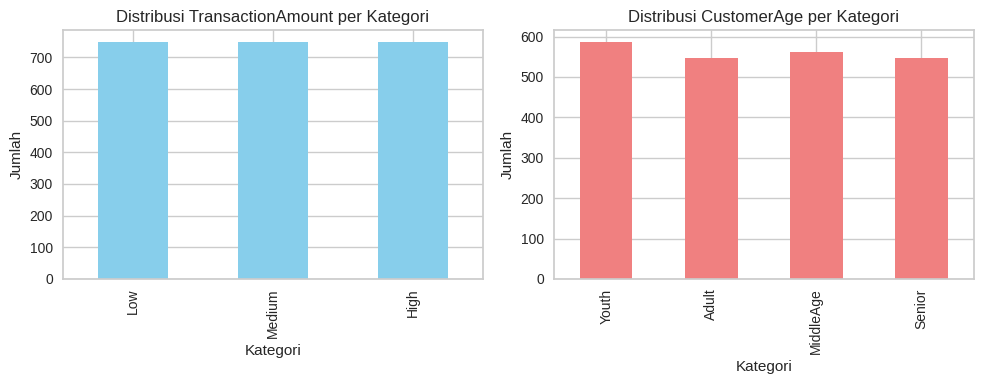


Catatan:
- Hasil binning ini tidak digunakan sebagai fitur input model KMeans,
  karena proses binning mengubah data kontinu menjadi kategori diskret yang dapat
  merusak perhitungan jarak Euclidean.
- Sebaliknya, hasil binning digunakan untuk analisis deskriptif dan interpretasi
  hasil cluster, agar lebih mudah menjelaskan karakteristik kelompok transaksi
  berdasarkan rentang nilai tertentu (misal: transaksi kategori High atau usia Senior).



In [21]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.

# BINNING FITUR NUMERIK
# Pilih dua fitur numerik untuk dibinning: TransactionAmount & CustomerAge

# TransactionAmount → 3 kategori (Low, Medium, High)
df['TransactionAmount_binned'], bins_amount = pd.qcut(
    df['TransactionAmount'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    retbins=True
)

# CustomerAge → 4 kategori (Youth, Adult, MiddleAge, Senior)
df['CustomerAge_binned'], bins_age = pd.qcut(
    df['CustomerAge'],
    q=4,
    labels=['Youth', 'Adult', 'MiddleAge', 'Senior'],
    retbins=True
)

# ENCODE HASIL BINNING
le_amount = LabelEncoder()
le_age = LabelEncoder()

df['TransactionAmount_binned_encoded'] = le_amount.fit_transform(df['TransactionAmount_binned'].astype(str))
df['CustomerAge_binned_encoded'] = le_age.fit_transform(df['CustomerAge_binned'].astype(str))

# TAMPILKAN HASIL BINNING
print("=== Contoh hasil binning dan encoding ===")
display(df[[
    'TransactionAmount', 'TransactionAmount_binned', 'TransactionAmount_binned_encoded',
    'CustomerAge', 'CustomerAge_binned', 'CustomerAge_binned_encoded'
]].head())

# TAMPILKAN BATAS NILAI BIN
print("\n=== Batas nilai setiap bin TransactionAmount ===")
for i in range(len(bins_amount) - 1):
    print(f"Bin {i+1}: {bins_amount[i]:.2f} – {bins_amount[i+1]:.2f}")

print("\n=== Batas nilai setiap bin CustomerAge ===")
for i in range(len(bins_age) - 1):
    print(f"Bin {i+1}: {bins_age[i]:.2f} – {bins_age[i+1]:.2f}")

# VISUALISASI DISTRIBUSI
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['TransactionAmount_binned'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title("Distribusi TransactionAmount per Kategori")
axes[0].set_xlabel("Kategori")
axes[0].set_ylabel("Jumlah")

df['CustomerAge_binned'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title("Distribusi CustomerAge per Kategori")
axes[1].set_xlabel("Kategori")
axes[1].set_ylabel("Jumlah")

plt.tight_layout()
plt.show()

# CATATAN PENTING
print("""
Catatan:
- Hasil binning ini tidak digunakan sebagai fitur input model KMeans,
  karena proses binning mengubah data kontinu menjadi kategori diskret yang dapat
  merusak perhitungan jarak Euclidean.
- Sebaliknya, hasil binning digunakan untuk analisis deskriptif dan interpretasi
  hasil cluster, agar lebih mudah menjelaskan karakteristik kelompok transaksi
  berdasarkan rentang nilai tertentu (misal: transaksi kategori High atau usia Senior).
""")


# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [22]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_outlier,LoginAttempts_flag,TransactionAmount_binned_encoded,CustomerAge_binned_encoded
count,2243.000000,2243.000000,2243.000000,2243.000000,2243.000000,2243.000000,2243.000000,2243.000000,2243.000000
mean,-0.001632,-0.004369,0.006626,1.120374,-0.002746,0.044583,0.037004,0.999554,1.522069
std,1.001331,1.001136,1.012463,0.585850,1.003574,0.206433,0.188814,0.816587,1.123041
min,-1.017881,-1.495947,-1.561745,1.000000,-1.285856,0.000000,0.000000,0.000000,0.000000
25%,-0.740476,-0.991288,-0.805299,1.000000,-0.929884,0.000000,0.000000,0.000000,1.000000
50%,-0.295362,0.018031,-0.105944,1.000000,-0.112942,0.000000,0.000000,1.000000,2.000000
75%,0.390056,0.803056,0.607683,1.000000,0.662907,0.000000,0.000000,2.000000,3.000000
max,5.549651,1.980594,2.577295,5.000000,2.531190,1.000000,1.000000,2.000000,3.000000


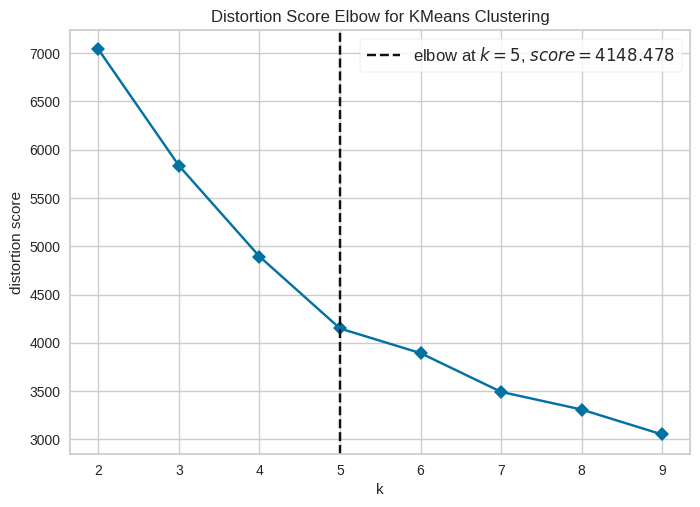


Catatan:
- Visualisasi Elbow ini menggunakan dataframe utama (df) yang telah discale sebelumnya.
- Tidak dilakukan scaling ulang atau pembuatan dataframe baru agar konsistensi pipeline terjaga.
- Hasil grafik Elbow akan identik dengan versi sebelumnya karena fitur numerik tetap sama.



In [23]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
# visualisasi elbow method

# 1. Pilih fitur numerik kontinu untuk clustering
# (tidak menggunakan hasil binning encoded)
features_continuous = [
    'TransactionAmount',
    'AccountBalance',
    'CustomerAge',
    'TransactionDuration'
]

# 2. Siapkan fitur flag tambahan (indikator outlier & perilaku mencurigakan)
features_flag = [
    'TransactionAmount_outlier',
    'LoginAttempts_flag'
]

# 3. Gunakan df yang sama — tanpa scaling ulang atau membuat dataframe baru
X = df[features_continuous + features_flag]

# 4. Inisialisasi model KMeans
model = KMeans(random_state=42)

# 5. Buat visualizer untuk range cluster (2–10)
visualizer = KElbowVisualizer(model, k=(2, 10), timings=False)

# 6. Fit langsung ke df
visualizer.fit(X)

# 7. Tampilkan plot elbow
visualizer.show()

print("""
Catatan:
- Visualisasi Elbow ini menggunakan dataframe utama (df) yang telah discale sebelumnya.
- Tidak dilakukan scaling ulang atau pembuatan dataframe baru agar konsistensi pipeline terjaga.
- Hasil grafik Elbow akan identik dengan versi sebelumnya karena fitur numerik tetap sama.
""")



In [24]:
# Menggunakan algoritma K-Means Clustering

# Inisialisasi model KMeans dengan 5 cluster
kmeans = KMeans(n_clusters=5, random_state=42)

# Latih model ke data hasil preprocessing
kmeans.fit(X)

# Simpan label cluster ke dataframe
df['Cluster'] = kmeans.labels_

# Cek distribusi cluster
print(df['Cluster'].value_counts())



Cluster
2    616
1    598
0    492
3    346
4    191
Name: count, dtype: int64


Jalankan cell code ini untuk menyimpan model kamu.

In [25]:
# Menyimpan model menggunakan joblib
# import joblib
joblib.dump(kmeans, "model_clustering.h5")

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [26]:
# Menghitung dan menampilkan nilai Silhouette Score.
# X = data hasil preprocessing
# df['Cluster'] = label cluster dari KMeans
score = silhouette_score(X, df['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.25995579118995354


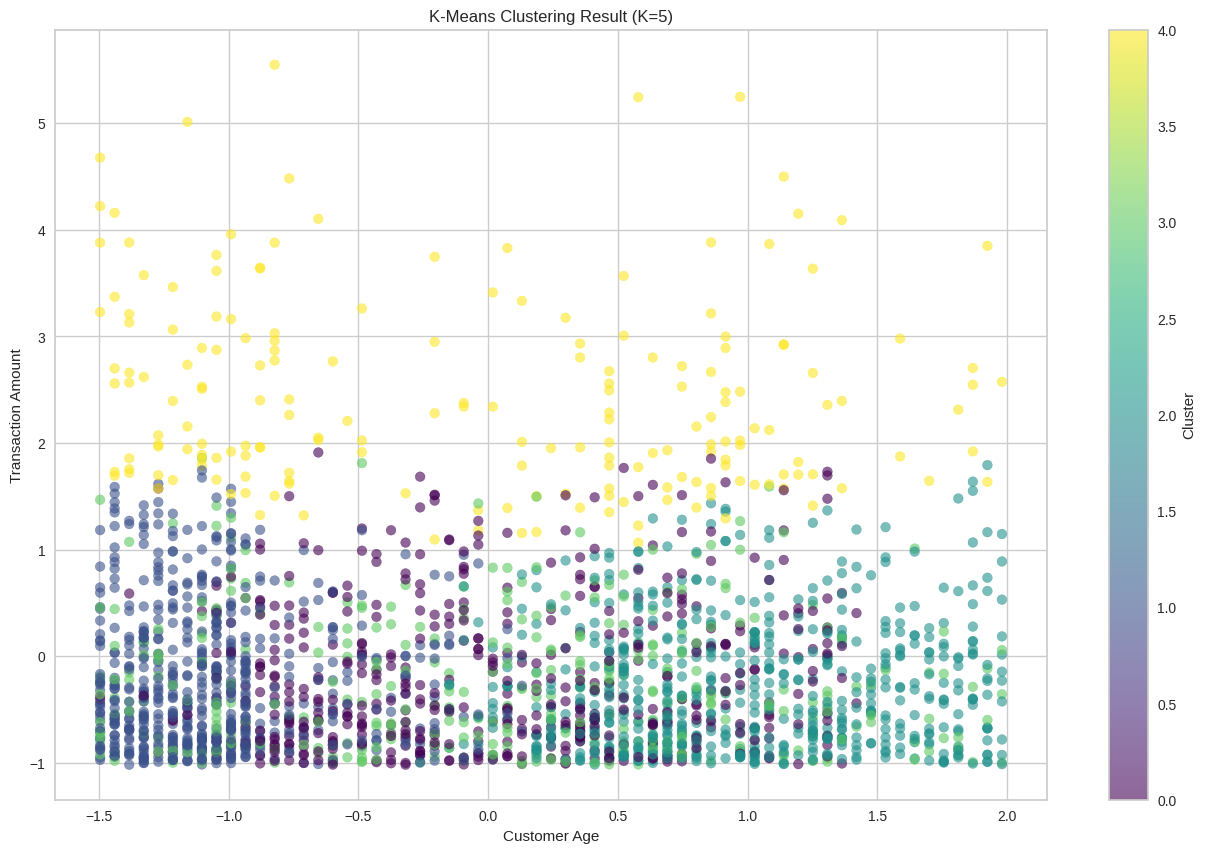

In [27]:
# Membuat visualisasi hasil clustering
plt.figure(figsize=(16,10))
plt.scatter(df['CustomerAge'], df['TransactionAmount'],
            c=df['Cluster'], cmap='viridis', alpha=0.6)

plt.xlabel("Customer Age")
plt.ylabel("Transaction Amount")
plt.title("K-Means Clustering Result (K=5)")
plt.colorbar(label="Cluster")
plt.show()

(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [29]:
# Membangun model menggunakan PCA.
pca =PCA(n_components=2)
X_pca = pca.fit_transform(X)
# Menyimpan data PCA sebagai Dataframe dengan nama PCA_<numbers>
PCA_2 = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
# Pastikan kamu membangun model Kmeans baru dengan data yang sudah dimodifikasi melalui PCA.
kmeans_pca = KMeans(n_clusters=5, random_state=42)   # pakai K=5 sesuai elbow sebelumnya
kmeans_pca.fit(PCA_2)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [30]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
# Pastikan yang disimpan model yang sudah melalui .fit berdasarkan dataset yang sudah dilakukan PCA
joblib.dump(pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Annual Income:** 0.953 (48,260)
  - **Rata-rata (mean) Spending Score:** 0.8 (56.48)
  - **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan tinggi dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang tinggi dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan yang berkualitas tinggi.


=== Statistik Deskriptif per Cluster (dalam skala StandardScaler) ===


TransactionAmount                                         CustomerAge  \
                     mean       min       max    median       std        mean   
Cluster                                                                         
0               -0.180751 -1.017676  1.911727 -0.394379  0.690152    0.015295   
1               -0.201851 -1.017881  1.743197 -0.370095  0.659023   -1.058238   
2               -0.285290 -1.015896  1.793064 -0.415856  0.598390    0.991120   
3               -0.239592 -1.014629  1.861380 -0.362394  0.625277    0.036182   
4                2.432529  1.064898  5.549651  2.207751  0.915097   -0.039510   

                                                 ...  \
              min       max    median       std  ...   
Cluster                                          ...   
0       -1.495947  1.419862 -0.038043  0.701546  ...   
1       -1.495947  0.130177 -1.103434  0.343469  ...   
2       -0.262336  1.980594  0.971276  0.537735  ...   
3       -1.495947  1.980594  0.074104  0.917014  ...   
4       -1.495947  1.980594  0.074104  1.003818  ...   

        TransactionAmount_binned_encoded                           \
                                    mean min max median       std   
Cluster                                                             
0                               1.048780   0   2    1.0  0.803289   
1                               1.085284   0   2    1.0  0.800597   
2                               1.123377   0   2    1.0  0.769989   
3                               1.112717   0   2    1.0  0.799645   
4                               0.000000   0   0    0.0  0.000000   

        CustomerAge_binned_encoded                           
                              mean min max median       std  
Cluster                                                      
0                         0.786585   0   3    1.0  0.896465  
1                         2.190635   0   3    3.0  1.326364  
2                         1.542208   0   2    2.0  0.557145  
3                         1.355491   0   3    1.0  1.091833  
4                         1.560209   0   3    2.0  1.116992  

[5 rows x 45 columns]


=== Ringkasan Nilai Mean per Cluster ===


,Cluster,TransactionAmount,AccountBalance,CustomerAge,TransactionDuration
0,0,-0.180751,1.315745,0.015295,-0.278810
1,1,-0.201851,-0.901497,-1.058238,-0.308385
2,2,-0.285290,-0.143611,0.991120,-0.405228
3,3,-0.239592,0.022229,0.036182,1.666492
4,4,2.432529,-0.176116,-0.039510,0.049559


<Figure size 1000x600 with 0 Axes>

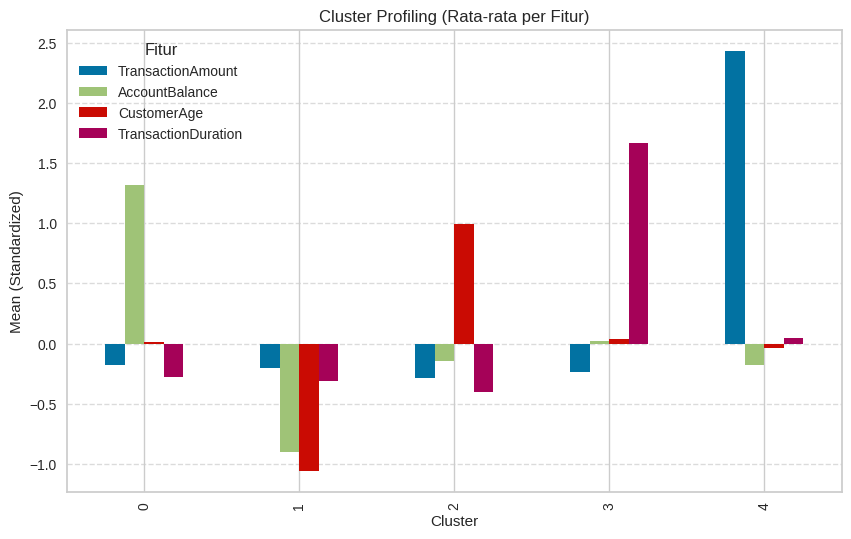


Catatan interpretasi:
- Nilai positif menunjukkan rata-rata fitur lebih tinggi dibandingkan rata-rata keseluruhan dataset (hasil StandardScaler).
- Nilai negatif berarti fitur tersebut lebih rendah dari rata-rata populasi.
- Cluster dengan nilai mean tinggi pada TransactionAmount dan AccountBalance menunjukkan kelompok pengguna dengan transaksi besar.
- Cluster dengan nilai tinggi pada LoginAttempts_flag atau TransactionAmount_outlier (jika ditambahkan) berpotensi mencerminkan pola perilaku mencurigakan atau indikasi fraud.



In [31]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.

# --- Statistik deskriptif per cluster ---
# Pilih hanya kolom numerik (kecuali cluster)
num_cols = df.select_dtypes(include=['float64', 'int64', 'int32']).columns.drop('Cluster')

# Hitung agregasi (mean, min, max, median, std)
cluster_stats = df.groupby('Cluster')[num_cols].agg(['mean', 'min', 'max', 'median', 'std'])

print("=== Statistik Deskriptif per Cluster (dalam skala StandardScaler) ===")
display(cluster_stats)

# --- Ringkasan mean untuk visualisasi ---
# Pilih beberapa fitur utama yang paling representatif
features_for_plot = ['TransactionAmount', 'AccountBalance', 'CustomerAge', 'TransactionDuration']

cluster_summary = df.groupby('Cluster')[features_for_plot].mean().reset_index()

print("\n=== Ringkasan Nilai Mean per Cluster ===")
display(cluster_summary)

# --- Visualisasi mean per cluster (Cluster Profiling) ---
plt.figure(figsize=(10,6))
cluster_summary.set_index('Cluster').plot(kind='bar', figsize=(10,6))
plt.title("Cluster Profiling (Rata-rata per Fitur)")
plt.ylabel("Mean (Standardized)")
plt.xlabel("Cluster")
plt.legend(title="Fitur")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- Catatan interpretasi ---
print("""
Catatan interpretasi:
- Nilai positif menunjukkan rata-rata fitur lebih tinggi dibandingkan rata-rata keseluruhan dataset (hasil StandardScaler).
- Nilai negatif berarti fitur tersebut lebih rendah dari rata-rata populasi.
- Cluster dengan nilai mean tinggi pada TransactionAmount dan AccountBalance menunjukkan kelompok pengguna dengan transaksi besar.
- Cluster dengan nilai tinggi pada LoginAttempts_flag atau TransactionAmount_outlier (jika ditambahkan) berpotensi mencerminkan pola perilaku mencurigakan atau indikasi fraud.
""")


## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya.

### **Nilai mean/median/std di sini masih dalam bentuk scaled (0–1), angka yang tercantum merupakan hasil dari normalisasi**

1. **Cluster 0 – Nasabah dengan Saldo Tinggi dan Transaksi kecil**:

  - **Rata-rata (mean) TransactionAmount:** -0.18

  - **Rata-rata (mean) AccountBalance:** +1.32
  - **Rata-rata (mean) CustomerAge:** +0.02
  - **Rata-rata (mean) TransactionDuration:** -0.28
  - **Analisis:** Cluster ini berisi nasabah dengan saldo rekening yang tinggi, tetapi memiliki jumlah per transaksinya yang cenderung kecil dan durasi aktivitas transaksi tidak terlalu lama.
  Berdasarkan analisis ini saya dapat menyimpulkan bahwa kemungkinan besar customer pada cluster ini menggunakan rekening ini sebagai tabungan utama.
  

2. **Cluster 1 – Nasabah Muda dengan Aktivitas dan Saldo Relatif Rendah**:

  - **Rata-rata (mean) TransactionAmount:** -0.20

  - **Rata-rata (mean)  AccountBalance:** -0.90

  - **Rata-rata (mean)  CustomerAge:** -1.06

  - **Rata-rata (mean) TransactionDuration:** -0.31

  - **Analisis:** Cluster ini mewakili nasabah muda dengan saldo rendah dan transaksi kecil serta waktu transaksi yang singkat.Kelompok ini bisa jadi pengguna baru atau pelanggan generasi muda yang belum aktif menggunakan layanan finansial secara penuh.

3. **Cluster 2 – Nasabah Senior dengan Aktivitas Transaksi sedang**:

  - **Rata-rata TransactionAmount**: -0.29

  - **Rata-rata AccountBalance**: -0.14

  - **Rata-rata CustomerAge**: +0.99

  - **Rata-rata TransactionDuration**: -0.40

  - **Analisis**: Cluster ini didominasi oleh nasabah usia lebih tua dengan aktivitas transaksi yang cukup stabil, namun tidak terlalu besar dalam jumlah uang maupun saldo.
  Mereka cenderung pengguna yang sudah mapan secara finansial, dengan perilaku transaksi konservatif.

4. **Cluster 3 – Nasabah Aktif dengan Durasi Transaksi Tinggi**:

  - **Rata-rata TransactionAmount**: -0.24

  - **Rata-rata AccountBalance**: +0.02

  - **Rata-rata CustomerAge**: +0.04

  - **Rata-rata TransactionDuration**: +1.67

  - **Analisis**: Cluster ini memiliki aktivitas transaksi dengan durasi tinggi, yang artinya pengguna sering melakukan transaksi panjang (misalnya pembayaran cicilan, transfer bertahap, atau aktivitas online banking lama).
Namun nominal dan saldo mereka relatif rata-rata.

5. **Cluster 4 – Nasabah Bertransaksi Besar dan Intensif –  Lebih berpotensi Fraud atau High Value User**:

  - **Rata-rata TransactionAmount**: +2.43

  - **Rata-rata AccountBalance**: -0.18

  - **Rata-rata CustomerAge**: -0.04

  - **Rata-rata TransactionDuration**: +0.05

  - **Analisis**: Cluster ini sangat menonjol karena memiliki nilai transaksi yang jauh di atas rata-rata global (lebih dari +2 SD).
Namun saldo mereka tidak terlalu tinggi, dan usia cenderung beragam.
Polanya menunjukkan bahwa pengguna ini melakukan transaksi besar namun saldo (AccountBalance) rendah, yang bisa mengindikasikan perilaku abnormal (potensi fraud) atau pengguna high-spending yang aktif.

# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [32]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
# Ubah nama kolom Cluster menjadi Target di dataframe utama
df.rename(columns={'Cluster': 'Target'}, inplace=True)

In [33]:
# Simpan Data
df.to_csv('data_clustering.csv', index=False)
print("File berhasil disimpan sebagai data_clustering.csv")

File berhasil disimpan sebagai data_clustering.csv


(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [34]:
# inverse dataset ke rentang normal untuk numerikal

numerical_cols_original = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'AccountBalance']
df[numerical_cols_original] = scaler.inverse_transform(df[numerical_cols_original])

# tampilkan dataset yang sudah di-inverse
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmount_outlier,LoginAttempts_flag,TransactionAmount_binned,CustomerAge_binned,TransactionAmount_binned_encoded,CustomerAge_binned_encoded,Target
0,14.09,680,1,36,0,70.0,0,81.0,1.0,5112.21,105,0,0,Low,Senior,1,2,2
1,376.24,1178,1,15,0,68.0,0,141.0,1.0,13758.91,192,0,0,High,Senior,0,2,0
2,126.29,1262,1,23,2,19.0,3,56.0,1.0,1122.35,41,0,0,Medium,Youth,2,3,1
3,184.50,818,1,33,2,26.0,3,25.0,1.0,8569.06,163,0,0,Medium,Youth,2,3,0
5,92.15,635,1,28,0,18.0,3,172.0,1.0,781.68,13,0,0,Low,Youth,1,3,1


In [35]:
# inverse dataset yang sudah diencode ke kategori aslinya.
# Lengkapi kode berikut jika ingin menerapkan kriteria ini (silakan hapus simbol pagar pada kode yang akan digunakan.)
categorical_cols = list(encoders.keys())
for col in categorical_cols:
    le = encoders[col]
    df[col] = le.inverse_transform(df[col].astype(int))
# tampilkan dataset yang sudah di-inverse
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmount_outlier,LoginAttempts_flag,TransactionAmount_binned,CustomerAge_binned,TransactionAmount_binned_encoded,CustomerAge_binned_encoded,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,0,0,Low,Senior,1,2,2
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,0,0,High,Senior,0,2,0
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,0,0,Medium,Youth,2,3,1
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,0,0,Medium,Youth,2,3,0
5,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 08:06:36,0,0,Low,Youth,1,3,1


In [36]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.

# Kolom numerik yang digunakan dalam clustering
numerical_cols_origin = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'AccountBalance']

# Kolom kategorikal (hanya eksploratif, tidak digunakan dalam model)
categorical_cols = list(encoders.keys()) if 'encoders' in locals() else []

# Analisis Numerik: Mean, Min, Max, Std per Cluster
print("=== Deskriptif Numerik (berdasarkan Cluster) ===")
num_desc = df.groupby('Target')[numerical_cols_origin].agg(['mean', 'min', 'max', 'std']).round(3)

# Analisis Kategorikal
categorical_desc = {}

for col in categorical_cols:
    categorical_desc[col] = df[col].value_counts(normalize=False).to_frame('Count')
    categorical_desc[col]['Percentage'] = (df[col].value_counts(normalize=True) * 100).round(2)

#display
display(num_desc)

for col, desc in categorical_desc.items():
    print(f"\n=== Deskriptif Kategorikal ({col}) ===")
    display(desc)

=== Deskriptif Numerik (berdasarkan Cluster) ===


TransactionAmount                           CustomerAge              \
                    mean     min      max      std        mean   min   max   
Target                                                                       
0                244.846    0.32   856.21  201.643      44.951  18.0  70.0   
1                238.681    0.26   806.97  192.548      25.806  18.0  47.0   
2                214.303    0.84   821.54  174.833      62.354  40.0  80.0   
3                227.654    1.21   841.50  182.689      45.324  18.0  80.0   
4               1008.374  608.79  1919.11  267.366      43.974  18.0  80.0   

               TransactionDuration                       AccountBalance  \
           std                mean    min    max     std           mean   
Target                                                                    
0       12.511              99.888   10.0  215.0  49.437      10241.158   
1        6.125              97.816   10.0  220.0  52.304       1600.125   
2        9.590              91.031   10.0  204.0  46.621       4553.758   
3       16.354             236.185  152.0  300.0  41.170       5200.068   
4       17.902             122.895   10.0  300.0  66.686       4427.078   

                                     
            min       max       std  
Target                               
0       5528.36  14977.99  2493.475  
1        102.20   7047.04  1513.128  
2        120.89   9073.17  2186.029  
3        135.96  14928.35  3425.230  
4        160.57  14881.77  3469.068


=== Deskriptif Kategorikal (TransactionDate) ===


,Count,Percentage
TransactionDate,,
2023-05-15 16:19:14,1,0.04
2023-04-11 16:29:14,1,0.04
2023-06-27 16:44:19,1,0.04
2023-05-10 17:56:31,1,0.04
2023-01-18 17:21:27,1,0.04
...,...,...
2023-03-21 16:59:46,1,0.04
2023-05-08 17:47:59,1,0.04
2023-02-15 16:36:48,1,0.04



=== Deskriptif Kategorikal (TransactionType) ===


,Count,Percentage
TransactionType,,
Debit,1737,77.44
Credit,506,22.56



=== Deskriptif Kategorikal (Location) ===


,Count,Percentage
Location,,
Oklahoma City,64,2.85
Fort Worth,63,2.81
Charlotte,62,2.76
Tucson,61,2.72
Philadelphia,58,2.59
Mesa,57,2.54
Los Angeles,57,2.54
Memphis,57,2.54
Seattle,57,2.54



=== Deskriptif Kategorikal (Channel) ===


,Count,Percentage
Channel,,
Branch,785,35.00
ATM,746,33.26
Online,712,31.74



=== Deskriptif Kategorikal (CustomerOccupation) ===


,Count,Percentage
CustomerOccupation,,
Student,593,26.44
Doctor,571,25.46
Engineer,549,24.48
Retired,530,23.63



=== Deskriptif Kategorikal (PreviousTransactionDate) ===


,Count,Percentage
PreviousTransactionDate,,
2024-11-04 08:09:17,15,0.67
2024-11-04 08:09:57,13,0.58
2024-11-04 08:12:18,13,0.58
2024-11-04 08:07:18,13,0.58
2024-11-04 08:11:40,13,0.58
...,...,...
2024-11-04 08:11:31,2,0.09
2024-11-04 08:09:10,2,0.09
2024-11-04 08:06:57,1,0.04


## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.


1. **Cluster 0 – Nasabah dengan Saldo Tinggi dan Transaksi kecil**:

  - **Rata-rata (mean) TransactionAmount:** -0.18 (244.85)

  - **Rata-rata (mean) AccountBalance:** +1.32 (10,241.16)
  - **Rata-rata (mean) CustomerAge:** +0.02 (44.95)
  - **Rata-rata (mean) TransactionDuration:** -0.28 (99.89)
  - **Analisis:** Cluster ini berisi nasabah dengan saldo rekening yang tinggi, tetapi memiliki jumlah per transaksinya yang cenderung kecil dan durasi aktivitas transaksi tidak terlalu lama.
  Berdasarkan analisis ini saya dapat menyimpulkan bahwa kemungkinan besar customer pada cluster ini menggunakan rekening ini sebagai tabungan utama.
  

2. **Cluster 1 – Nasabah Muda dengan Aktivitas dan Saldo Relatif Rendah**:

  - **Rata-rata (mean) TransactionAmount:** -0.20 (238.68)

  - **Rata-rata (mean)  AccountBalance:** -0.90 (1,600.13)

  - **Rata-rata (mean)  CustomerAge:** -1.06 (25.81)

  - **Rata-rata (mean) TransactionDuration:** -0.31 (97.82)

  - **Analisis:** Cluster ini mewakili nasabah muda dengan saldo rendah dan transaksi kecil serta waktu transaksi yang singkat.Kelompok ini bisa jadi pengguna baru atau pelanggan generasi muda yang belum aktif menggunakan layanan finansial secara penuh.

3. **Cluster 2 – Nasabah Senior dengan Aktivitas Transaksi sedang**:

  - **Rata-rata TransactionAmount**: -0.29 (214.30)

  - **Rata-rata AccountBalance**: -0.14 (4,553.76)

  - **Rata-rata CustomerAge**: +0.99 (62.35)

  - **Rata-rata TransactionDuration**: -0.40 (91.03)

  - **Analisis**: Cluster ini terdiri dari nasabah berusia senior (sekitar 62 tahun) dengan aktivitas transaksi stabil dan nominal moderat. Yang berada dalam cluster ini cukup berhati-hati dan jarang melakukan transaksi berisiko dan bernilai besar.

4. **Cluster 3 – Nasabah Aktif dengan Durasi Transaksi Tinggi**:

  - **Rata-rata TransactionAmount**: -0.24 (227.65)

  - **Rata-rata AccountBalance**: +0.02 (5,200.07)

  - **Rata-rata CustomerAge**: +0.04 (45.32)

  - **Rata-rata TransactionDuration**: +1.67 (236.19)

  - **Analisis**: Cluster ini ditandai oleh durasi transaksi yang tinggi (sekitar 236 detik),
menunjukkan adanya aktivitas transaksi berulang atau kompleks, misalnya pembayaran cicilan atau transfer bertahap.
Nominal dan saldo rata-rata tidak terlalu besar, tetapi aktivitasnya intens.

5. **Cluster 4 – Nasabah Bertransaksi Besar dan Intensif –  Lebih berpotensi Fraud atau High Value User**:

  - **Rata-rata TransactionAmount**: +2.43 (1,008.37)

  - **Rata-rata AccountBalance**: -0.18 (4,427.08)

  - **Rata-rata CustomerAge**: -0.04 (43.97)

  - **Rata-rata TransactionDuration**: +0.05 (122.90)

  - **Analisis**: Cluster ini paling menonjol dengan nilai transaksi jauh di atas rata-rata (sekitar 1.000),
namun saldo tidak sebanding (rata-rata 4.400) dan usia pengguna beragam.
Kombinasi transaksi besar dengan saldo rendah dapat mengindikasikan aktivitas abnormal (fraud) atau high-spending user.

(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [37]:
# Mengintegrasikan kembali data yang telah di-inverse dengan hasil cluster.
# karena saya hanya menggunakan satu df saja, maka sudah otomatis terintergrasi sehingga

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2243 entries, 0 to 2535
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   TransactionAmount                 2243 non-null   float64 
 1   TransactionDate                   2243 non-null   object  
 2   TransactionType                   2243 non-null   object  
 3   Location                          2243 non-null   object  
 4   Channel                           2243 non-null   object  
 5   CustomerAge                       2243 non-null   float64 
 6   CustomerOccupation                2243 non-null   object  
 7   TransactionDuration               2243 non-null   float64 
 8   LoginAttempts                     2243 non-null   float64 
 9   AccountBalance                    2243 non-null   float64 
 10  PreviousTransactionDate           2243 non-null   object  
 11  TransactionAmount_outlier         2243 non-null   int64   
 1

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmount_outlier,LoginAttempts_flag,TransactionAmount_binned,CustomerAge_binned,TransactionAmount_binned_encoded,CustomerAge_binned_encoded,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,0,0,Low,Senior,1,2,2
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,0,0,High,Senior,0,2,0
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,0,0,Medium,Youth,2,3,1
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,0,0,Medium,Youth,2,3,0
5,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 08:06:36,0,0,Low,Youth,1,3,1


In [38]:
# Simpan Data
df.to_csv('data_clustering_inverse.csv', index=False)

End of Code.